In [1]:
import numpy as np
import pandas as pd
import os

# 直接使用固定路径
data_dir = "/Users/huangwenqin/Desktop/AIF+CALC+SSF PROJs/CALC_EOCPROJ/python_code/experiment_3/run03"
print(f"数据目录: {data_dir}")

# 角度组：5°, 15°, 45°, 60°, 90°
angle_groups = [5, 15, 45, 60, 90]

# 用字典存储所有 DataFrame
dfs = {}

for angle in angle_groups:
    base_num = angle_groups.index(angle) * 2 + 1
    micro_num = base_num + 1
    
    base_file = os.path.join(data_dir, f"run_03_angle_{angle:02d}deg_{base_num:03d}_baseline_RK4_0.0100_1200s.csv")
    micro_file = os.path.join(data_dir, f"run_03_angle_{angle:02d}deg_{micro_num:03d}_micro_RK4_0.0100_1200s.csv")
    
    dfs[(angle, "baseline")] = pd.read_csv(base_file)
    dfs[(angle, "micro")] = pd.read_csv(micro_file)

print("✅ 所有数据读取成功")

数据目录: /Users/huangwenqin/Desktop/AIF+CALC+SSF PROJs/CALC_EOCPROJ/python_code/experiment_3/run03
✅ 所有数据读取成功


In [2]:
# ========== 1. 每组每条线的两个角度存为 list ==========
angle_lists = {}

for angle in angle_groups:
    for typ in ["baseline", "micro"]:
        df = dfs[(angle, typ)]
        angle_lists[(angle, typ)] = df[["theta_1", "theta_2"]].values.tolist()

In [3]:
# ========== 2. 组内求欧几里得距离 ==========
distance_tables = {}

for angle in angle_groups:
    baseline_arr = np.array(angle_lists[(angle, "baseline")])
    micro_arr   = np.array(angle_lists[(angle, "micro")])
    
    diffs = baseline_arr - micro_arr
    distances = np.sqrt(np.sum(diffs**2, axis=1))
    
    distance_tables[angle] = distances.tolist()

print("✅ angle_lists 和 distance_tables 已生成")
print(f"   角度组: {angle_groups}")
print(f"   每组距离数量: {len(distance_tables[5])} 个时间步")

✅ angle_lists 和 distance_tables 已生成
   角度组: [5, 15, 45, 60, 90]
   每组距离数量: 120000 个时间步


In [4]:
# 示例验证
print("5°组 前5步欧氏距离:")
print(distance_tables[5][:5])
print()
print("90°组 前5步欧氏距离:")
print(distance_tables[90][:5])

5°组 前5步欧氏距离:
[9.999999999976694e-05, 9.990230893615122e-05, 9.960966344681314e-05, 9.912334715304262e-05, 9.844550144593996e-05]

90°组 前5步欧氏距离:
[0.00010000000000331966, 9.999997594434335e-05, 9.999961507408322e-05, 9.999805130198118e-05, 9.999384154946523e-05]


## 画图

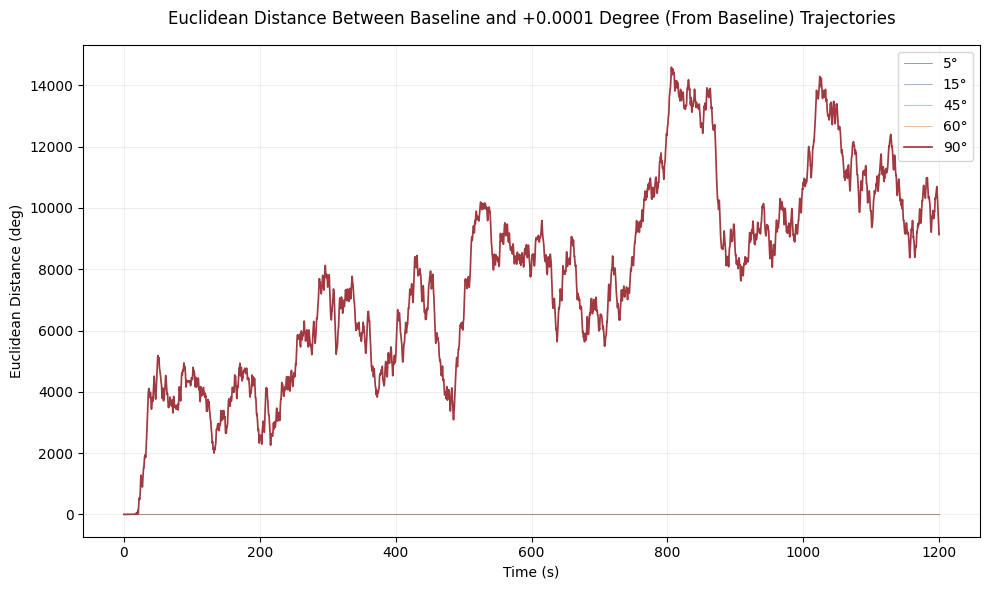

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 时间轴 (dt=0.01, 1200s -> 120000步)
time = np.arange(len(distance_tables[5])) * 0.01

angle_color_palette = {
    5: "#2B4C7E",
    15: "#4A7BB0",
    45: "#689F9E",
    60: "#E28743",
    90: "#A13941"
}

# ---- 图1：欧氏距离随时间变化 ----
fig, ax_main = plt.subplots(figsize=(10, 6))

for angle in angle_groups:
    if angle != 90:
        lw = 0.5
        alpha = 0.75
    else:
        lw = 1.25
        alpha = 1.0
    ax_main.plot(time, distance_tables[angle], label=f"{angle}°", linewidth=lw, alpha=alpha, color=angle_color_palette[angle])

ax_main.set_xlabel("Time (s)")
ax_main.set_ylabel("Euclidean Distance (deg)")
ax_main.set_title("Euclidean Distance Between Baseline and +0.0001 Degree (From Baseline) Trajectories", pad=15)
ax_main.legend(loc="upper right")
ax_main.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.savefig("experiment_3.png", dpi=600, bbox_inches='tight')
plt.savefig("experiment_3.pdf", bbox_inches='tight')
plt.show()